In [1]:
# ============================================================
#               HANDWRITTEN DIGIT RECOGNITION USING CNN
# ============================================================

# ================= IMPORT LIBRARIES =================

# Numerical computations ke liye NumPy import kar rahe hain.
import numpy as np

# Data visualization ke liye Matplotlib import kar rahe hain.
import matplotlib.pyplot as plt

# TensorFlow ka Keras API use karenge model banane ke liye.
import tensorflow as tf

# MNIST handwritten digit dataset load karne ke liye.
from tensorflow.keras.datasets import mnist

# Labels ko One-Hot Encoding me convert karne ke liye.
from tensorflow.keras.utils import to_categorical

# CNN Layers import kar rahe hain.
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Data Augmentation ke liye.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training callbacks.
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

# Evaluation ke liye.
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [2]:
# ================= LOAD DATASET =================

# MNIST dataset load kar rahe hain.
# x_train -> Training Images
# y_train -> Training Labels
# x_test -> Testing Images
# y_test -> Testing Labels

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


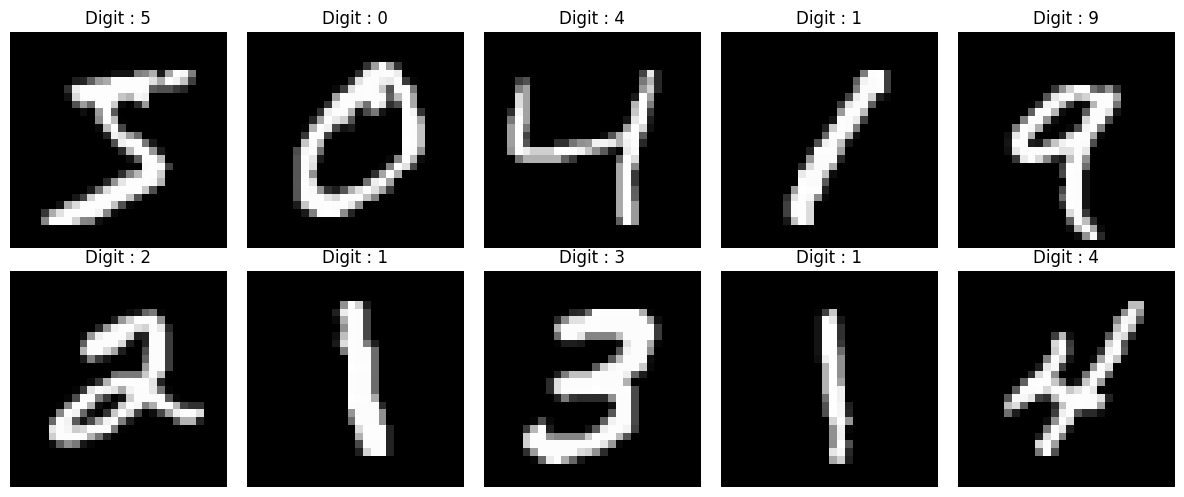

In [3]:
# ================= VISUALIZE DATASET =================

# First 10 handwritten digits display kar rahe hain.

plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(f"Digit : {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [4]:
# ================= IMAGE NORMALIZATION =================

# Pixel values 0-255 hoti hain.
# Inhe 0-1 range me convert karenge.
# Neural Network normalized data par better perform karta hai.

x_train = x_train.astype("float32") / 255.0

x_test = x_test.astype("float32") / 255.0

In [5]:
# ================= RESHAPE IMAGES =================

# CNN ko channel dimension chahiye.
# Isliye image shape:
# (28,28)
# se
# (28,28,1)
# bana rahe hain.

x_train = x_train.reshape(-1,28,28,1)

x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)

print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [6]:
# ================= ONE HOT ENCODING =================

# Labels:
# 5
# ko
# [0 0 0 0 0 1 0 0 0 0]
# me convert kar rahe hain.

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [7]:
# ================= DATA AUGMENTATION =================

# Real world images ko simulate karne ke liye
# training images ko randomly modify karenge.

datagen = ImageDataGenerator(

    # Random Rotation
    rotation_range=20,

    # Random Zoom
    zoom_range=0.20,

    # Left Right Shift
    width_shift_range=0.20,

    # Up Down Shift
    height_shift_range=0.20,

    # Random Shear
    shear_range=0.20

)

# Augmentation statistics prepare kar raha hai.
datagen.fit(x_train)

In [8]:
# ================= BUILD CNN MODEL =================

# Sequential Model create kar rahe hain.
# Layers ek ke baad ek execute hongi.
model = Sequential([

    # ===================================================
    # FIRST CONVOLUTION BLOCK
    # ===================================================

    # First Convolution Layer
    # 32 filters use kar rahe hain.
    # Har filter image se different feature learn karega.
    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation="relu",

        padding="same",

        input_shape=(28,28,1)

    ),

    # Second Convolution Layer
    # Complex features learn karega.
    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation="relu"

    ),

    # MaxPooling
    # Image size reduce karega.
    # Important features preserve karega.
    MaxPooling2D(

        pool_size=(2,2)

    ),

    # ===================================================
    # SECOND CONVOLUTION BLOCK
    # ===================================================

    # 64 filters use kar rahe hain.
    # Deep features learn honge.
    Conv2D(

        filters=64,

        kernel_size=(3,3),

        activation="relu",

        padding="same"

    ),

    Conv2D(

        filters=64,

        kernel_size=(3,3),

        activation="relu"

    ),

    MaxPooling2D(

        pool_size=(2,2)

    ),

    # ===================================================
    # FLATTEN
    # ===================================================

    # 2D Feature Maps ko 1D Vector me convert karega.
    Flatten(),

    # ===================================================
    # DENSE LAYER
    # ===================================================

    # Fully Connected Layer
    Dense(

        units=256,

        activation="relu"

    ),

    # Dropout
    # Overfitting reduce karta hai.
    # Training ke time random neurons ko disable karta hai.
    Dropout(

        0.5

    ),

    # ===================================================
    # OUTPUT LAYER
    # ===================================================

    # 10 Digits
    # 0 se 9 tak
    Dense(

        units=10,

        activation="softmax"

    )

])

c:\Users\Prateek Verma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# ================= MODEL SUMMARY =================

# Model ki architecture display karega.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,418 (1.82 MB)

 Trainable params: 477,418 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ================= COMPILE MODEL =================

# Adam Optimizer
# Fast aur efficient optimizer hai.

# Categorical Crossentropy
# Multi-Class Classification ke liye use hota hai.

# Accuracy
# Model ki performance measure karega.

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [11]:
# ================= EARLY STOPPING =================

# Agar Validation Accuracy improve nahi hoti
# to training automatically stop ho jayegi.

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [12]:
# ================= MODEL CHECKPOINT =================

# Best model automatically save hoga.

checkpoint = ModelCheckpoint(

    "cnn_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [13]:
# ================= TRAIN MODEL =================

history = model.fit(

    # Augmented Images batches me model ko bhej rahe hain.
    datagen.flow(

        x_train,

        y_train,

        batch_size=32

    ),

    # Original Test Data Validation ke liye use hoga.
    validation_data=(

        x_test,

        y_test

    ),

    # Maximum Training Epochs
    epochs=25,

    # Callbacks
    callbacks=[

        early_stop,

        checkpoint

    ]

)

Epoch 1/25
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8578 - loss: 0.4454
Epoch 1: val_accuracy improved from None to 0.98390, saving model to cnn_model.keras

Epoch 1: finished saving model to cnn_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.8578 - loss: 0.4453 - val_accuracy: 0.9839 - val_loss: 0.0480
Epoch 2/25
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9563 - loss: 0.1466
Epoch 2: val_accuracy improved from 0.98390 to 0.98750, saving model to cnn_model.keras

Epoch 2: finished saving model to cnn_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9563 - loss: 0.1466 - val_accuracy: 0.9875 - val_loss: 0.0377
Epoch 3/25
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9671 - loss: 0.1115
Epoch 3: val_accuracy improved from 0.98750 to 0.98900, saving model to cnn_model.keras

Epoch 3: finished saving model to cnn_model.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9671 - loss: 0.111

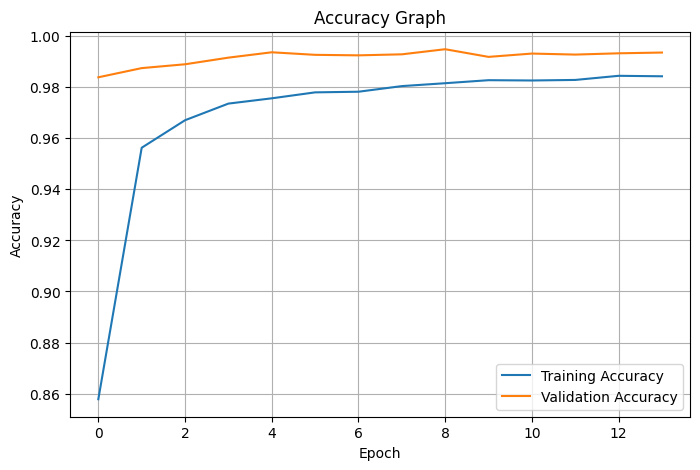

In [14]:
# ================= TRAINING ACCURACY =================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Accuracy Graph")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

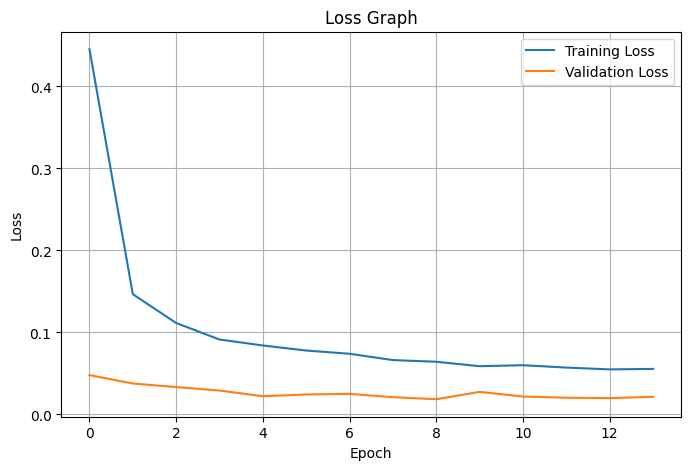

In [15]:
# ================= TRAINING LOSS =================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Loss Graph")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
# ================= MODEL EVALUATION =================

# Test Dataset par model ki final performance check kar rahe hain.

test_loss, test_accuracy = model.evaluate(

    x_test,

    y_test,

    verbose=1

)

print("\n=====================================")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("=====================================")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9949 - loss: 0.0186

Test Accuracy : 99.49%
Test Loss     : 0.0186


In [17]:
# ================= MODEL PREDICTION =================

# Test Images ke predictions nikal rahe hain.

predictions = model.predict(

    x_test,

    verbose=1

)

# Softmax probabilities ko actual digit me convert kar rahe hain.

predicted_labels = np.argmax(

    predictions,

    axis=1

)

# One Hot Labels ko actual labels me convert kar rahe hain.

true_labels = np.argmax(

    y_test,

    axis=1

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


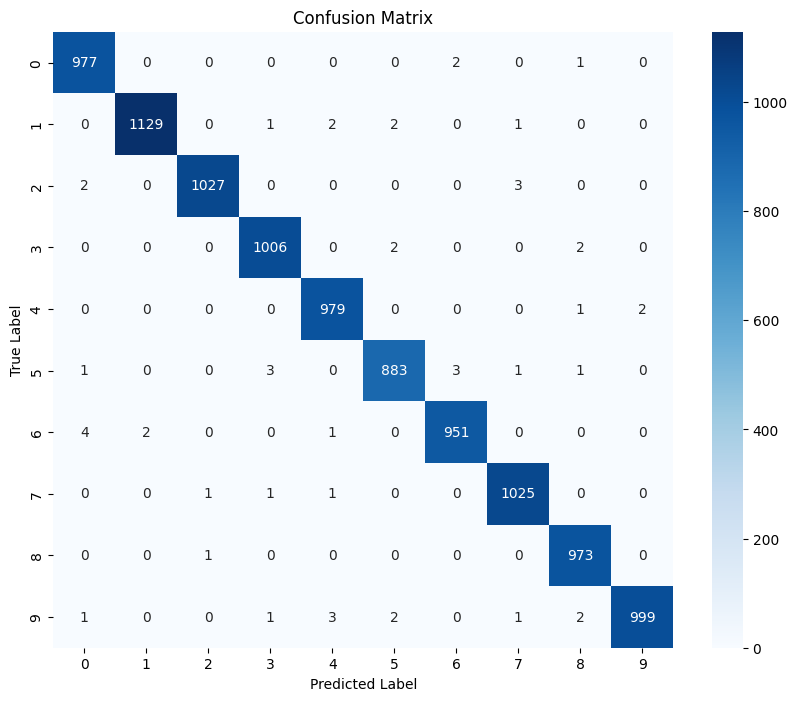

In [18]:
# ================= CONFUSION MATRIX =================

# Confusion Matrix batata hai
# kaunsa digit kis digit ke saath confuse hua.

cm = confusion_matrix(

    true_labels,

    predicted_labels

)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [19]:
# ================= CLASSIFICATION REPORT =================

# Precision
# Recall
# F1 Score
# Support

print(

    classification_report(

        true_labels,

        predicted_labels

    )

)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      1.00      1028
           8       0.99      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



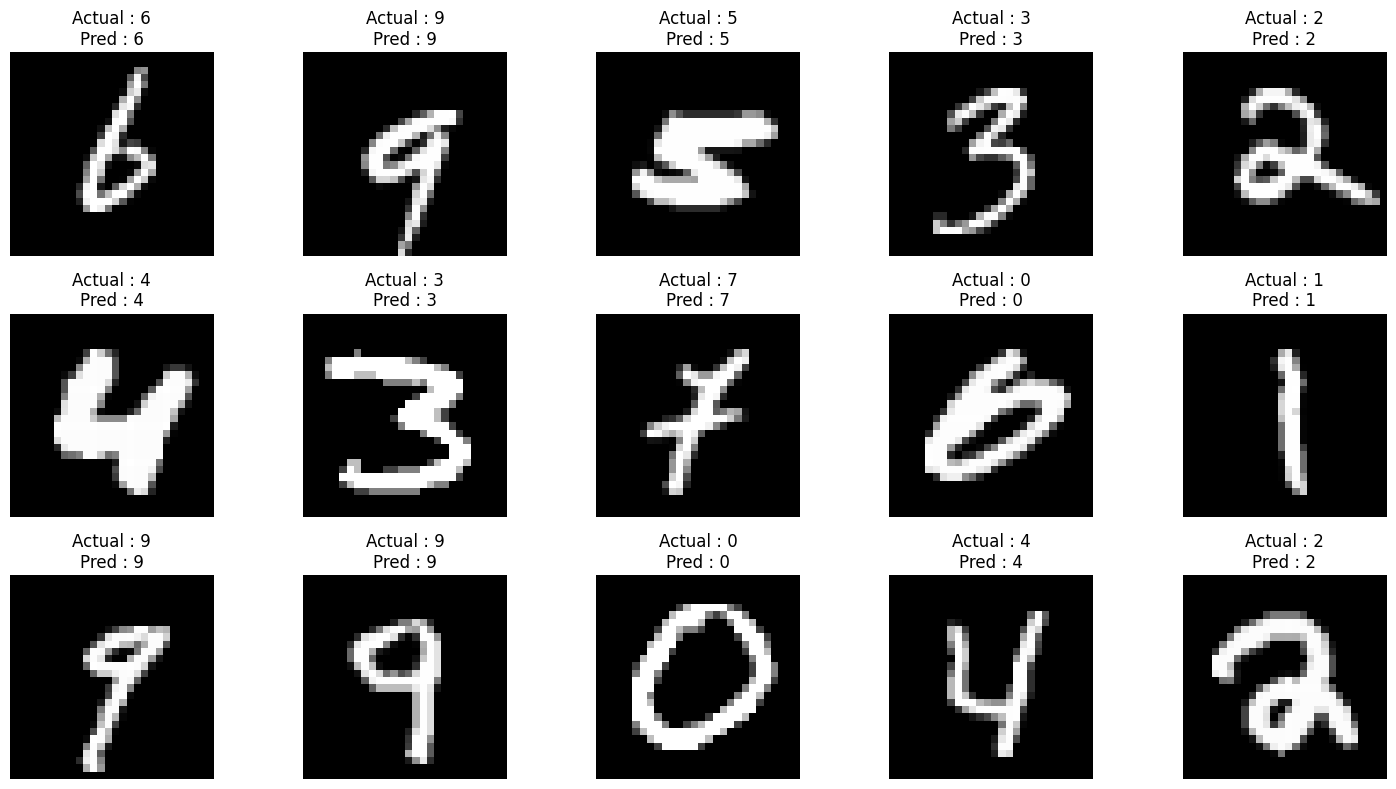

In [20]:
# ================= RANDOM PREDICTIONS =================

# Random test images aur unki prediction display karenge.

plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    index = np.random.randint(0, len(x_test))

    plt.imshow(

        x_test[index].reshape(28,28),

        cmap="gray"

    )

    plt.title(

        f"Actual : {true_labels[index]}\nPred : {predicted_labels[index]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

Wrong Predictions : 51


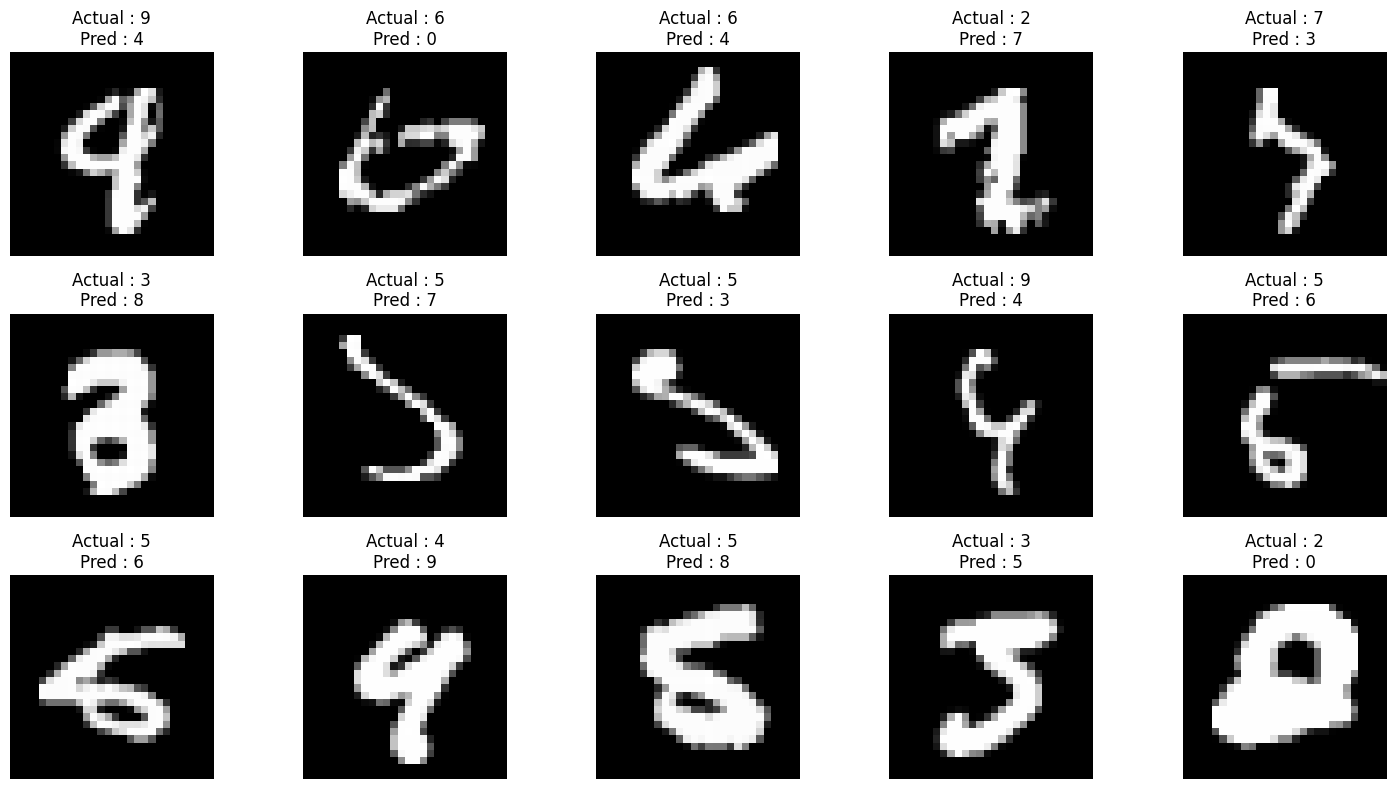

In [21]:
# ================= WRONG PREDICTIONS =================

# Sirf galat predicted images display karenge.

wrong = np.where(

    predicted_labels != true_labels

)[0]

print(f"Wrong Predictions : {len(wrong)}")

plt.figure(figsize=(15,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(

        x_test[wrong[i]].reshape(28,28),

        cmap="gray"

    )

    plt.title(

        f"Actual : {true_labels[wrong[i]]}\nPred : {predicted_labels[wrong[i]]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [22]:
# ================= SAVE MODEL =================

# Final trained CNN model save kar rahe hain.

model.save(
    "cnn_model.keras"
)

print("\nModel Saved Successfully.")


Model Saved Successfully.
